In [ ]:
# install the medmnist package — gives us access to PneumoniaMNIST and other medical datasets
!pip install medmnist -q

# core imports: numpy for arrays, torch for building/training the model,
# DataLoader for batching data, transforms for preprocessing images
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from medmnist import PneumoniaMNIST

# use GPU if colab gives us one, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# preprocessing: convert images to tensors, then normalize pixel values
# to roughly [-1, 1] — helps the model train faster and more stably
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# load the three splits: train (to learn from), val (to check progress),
# test (final, unseen accuracy check) — download=True grabs the data automatically
train_dataset = PneumoniaMNIST(split='train', transform=data_transform, download=True)
val_dataset = PneumoniaMNIST(split='val', transform=data_transform, download=True)
test_dataset = PneumoniaMNIST(split='test', transform=data_transform, download=True)

# sanity check — confirm how many images are in each split
print(f'train: {len(train_dataset)} | val: {len(val_dataset)} | test: {len(test_dataset)}')

# wrap each dataset in a DataLoader — batches of 64 images at a time,
# shuffled for training so the model doesn't memorize order
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

device: cpu
train: 4708 | val: 524 | test: 624


In [ ]:
# define the CNN architecture — this is the "brain" that learns to spot pneumonia
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # feature extractor: scans the image for patterns (edges, textures, shapes)
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # 1 grayscale channel in, 16 filters out
            nn.ReLU(),                                    # adds non-linearity so the model can learn complex patterns
            nn.MaxPool2d(2),  # shrinks image size 28 -> 14, keeps the strongest features

            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # deepens the network — 16 filters in, 32 out
            nn.ReLU(),
            nn.MaxPool2d(2),  # shrinks again 14 -> 7
        )

        # classifier: takes the extracted features and decides normal vs pneumonia
        self.classifier = nn.Sequential(
            nn.Flatten(),                    # flattens the 3D feature map into a 1D list
            nn.Linear(32 * 7 * 7, 64),        # fully connected layer, compresses down to 64 values
            nn.ReLU(),
            nn.Dropout(0.3),                  # randomly turns off 30% of neurons during training — prevents overfitting
            nn.Linear(64, 1)                  # final output: one number (higher = more likely pneumonia)
        )

    def forward(self, x):
        # defines how data flows through the model: image -> features -> classifier -> prediction
        x = self.features(x)
        x = self.classifier(x)
        return x

# create the model and move it to GPU (or CPU)
model = PneumoniaCNN().to(device)
print(model)

# quick check — how many learnable parameters (weights) does this model have?
print('total params:', sum(p.numel() for p in model.parameters()))

PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
total params: 105281


In [ ]:
import time

# loss function: measures how wrong the model's predictions are (for binary yes/no problems)
criterion = nn.BCEWithLogitsLoss()

# optimizer: updates the model's weights to reduce that loss over time
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# how many times we loop through the entire training set
EPOCHS = 10
start_time = time.time()

for epoch in range(EPOCHS):
    # --- training phase ---
    model.train()  # puts the model in "learning mode" (dropout is active)
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()                          # clear old gradients from the last batch
        outputs = model(images).squeeze(1)              # run the images through the model
        loss = criterion(outputs, labels.squeeze(1))     # compare prediction vs actual label
        loss.backward()                                  # calculate how to adjust the weights
        optimizer.step()                                  # actually update the weights
        running_loss += loss.item()                       # track loss for this batch

    # --- validation phase ---
    model.eval()  # puts the model in "testing mode" (dropout turned off)
    correct, total = 0, 0

    with torch.no_grad():  # no need to track gradients here, we're just checking accuracy
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float().squeeze(1)
            outputs = torch.sigmoid(model(images).squeeze(1))  # sigmoid converts raw output to a 0-1 probability
            preds = (outputs > 0.5).float()                     # above 0.5 = predict pneumonia
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # print progress after each epoch — watch the accuracy climb as training goes
    print(f'epoch {epoch+1}/{EPOCHS} | loss: {running_loss/len(train_loader):.4f} | val acc: {100*correct/total:.2f}%')

elapsed = time.time() - start_time

# total time spent training — good for your "took X minutes" line in the video
print(f'\ntraining time: {elapsed/60:.1f}')

epoch 1/10 | loss: 0.3494 | val acc: 90.27%
epoch 2/10 | loss: 0.1746 | val acc: 94.08%
epoch 3/10 | loss: 0.1391 | val acc: 94.47%
epoch 4/10 | loss: 0.1316 | val acc: 95.61%
epoch 5/10 | loss: 0.1301 | val acc: 95.61%
epoch 6/10 | loss: 0.1214 | val acc: 95.61%
epoch 7/10 | loss: 0.1130 | val acc: 95.04%
epoch 8/10 | loss: 0.1034 | val acc: 95.80%
epoch 9/10 | loss: 0.1053 | val acc: 95.80%
epoch 10/10 | loss: 0.0963 | val acc: 96.37%

training time: 0.7


In [ ]:
# switch to evaluation mode — turns off dropout so predictions are consistent
model.eval()

correct, total = 0, 0

# no gradient tracking needed here — we're just measuring accuracy, not training
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float().squeeze(1)

        outputs = torch.sigmoid(model(images).squeeze(1))  # convert raw output to a 0-1 probability
        preds = (outputs > 0.5).float()                     # above 0.5 = model predicts pneumonia

        correct += (preds == labels).sum().item()           # count how many predictions matched the true label
        total += labels.size(0)

# this is the real, unbiased accuracy number — the test set was never seen during training
test_acc = 100 * correct / total
print(f'FINAL TEST ACCURACY: {test_acc:.2f}%')

FINAL TEST ACCURACY: 84.94%


In [ ]:
# save just the model's learned weights (not the whole architecture) to a file
torch.save(model.state_dict(), 'pneumonia_model.pth')
print('saved: pneumonia_model.pth')

# trigger a browser download so the file lands on your actual computer —
# you'll need this file later to plug into your app's backend
from google.colab import files
files.download('pneumonia_model.pth')

saved: pneumonia_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

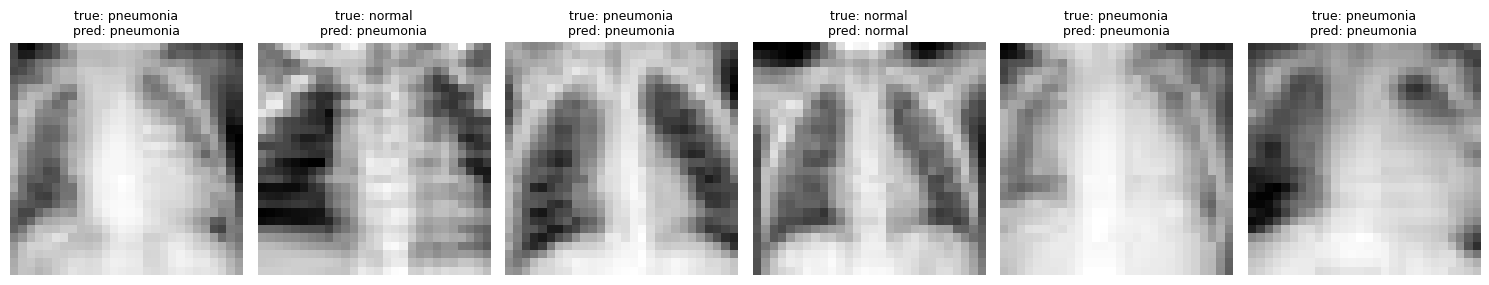

In [ ]:
import matplotlib.pyplot as plt

# grab one batch of test images to visualize — next(iter(...)) pulls the first batch
images, labels = next(iter(test_loader))
images_gpu = images.to(device)

# run predictions on this batch, no need to track gradients since we're not training
with torch.no_grad():
    preds = torch.sigmoid(model(images_gpu).squeeze(1)) > 0.5  # True = predicted pneumonia

# set up a row of 6 side-by-side images
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i, ax in enumerate(axes):
    img = images[i][0].numpy()  # pull out the raw image array for display
    true_label = 'pneumonia' if labels[i].item() == 1 else 'normal'   # the real, correct answer
    pred_label = 'pneumonia' if preds[i].item() == 1 else 'normal'    # what the model guessed

    ax.imshow(img, cmap='gray')  # show the x-ray in grayscale
    ax.set_title(f'true: {true_label}\npred: {pred_label}', fontsize=9)  # label with real vs predicted
    ax.axis('off')  # hide the axis ticks/numbers, keep it clean for the video

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)  # saves an image file — good for a screen recording or carousel slide
plt.show()

In [ ]:
# ---------------------------------------------------------
# WANT TO PUSH ACCURACY HIGHER? try these, one at a time:
# ---------------------------------------------------------

# 1. train for more epochs
#    change EPOCHS = 10 to EPOCHS = 20 or 30 in the training cell
#    more passes over the data = more chances to learn patterns
#    (watch for the val accuracy plateauing — that's when to stop)

# 2. add data augmentation
#    randomly flip/rotate/shift training images slightly so the model
#    sees more variation and doesn't just memorize the training set
#    example: add transforms.RandomHorizontalFlip() to data_transform

# 3. go deeper — add another conv layer
#    one more nn.Conv2d + nn.ReLU + nn.MaxPool2d block in self.features
#    lets the model learn more complex patterns (but risks overfitting
#    on a small dataset, so watch val accuracy closely)

# 4. lower the learning rate
#    change lr=1e-3 to lr=5e-4 in the optimizer
#    smaller steps = more precise learning, especially in later epochs

# 5. try class weighting
#    if pneumonia/normal images aren't evenly split, the model can get
#    lazy and just guess the majority class — check your class balance
#    and add pos_weight to BCEWithLogitsLoss if it's skewed

# 6. use a pretrained model instead of training from scratch
#    swap this custom CNN for a pretrained one like ResNet18, fine-tuned
#    on this dataset — usually the single biggest accuracy jump, but
#    also the most advanced option here